# Lab 10

Used libraries:

In [68]:
import nidaqmx
import time

import numpy as np
import numpy.typing
from typing import Tuple

import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, ProductCategory
from nidaqmx.constants import TerminalConfiguration
from nidaqmx.constants import AcquisitionType, READ_ALL_AVAILABLE, LineGrouping

import pandas as pd

import scipy as sp
from scipy.signal.windows import hann, blackmanharris

# Task 1


C:\Users\leoni\AppData\Local\Temp\ipykernel_28868\2072125684.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


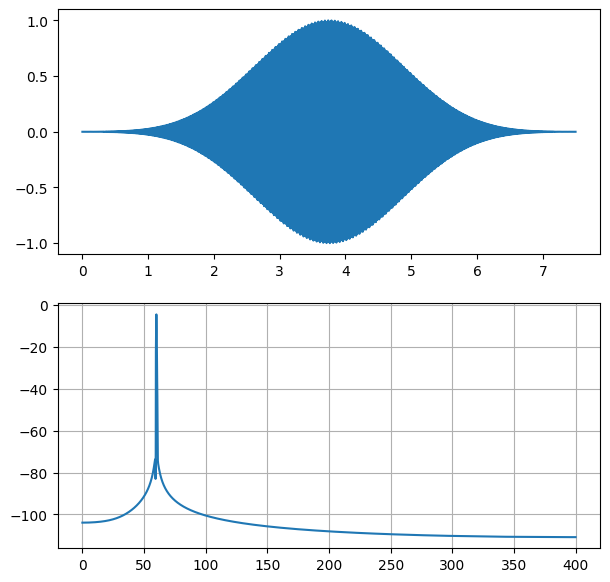

In [71]:
#stolen and modified from https://docs.scipy.org/doc/scipy/tutorial/fft.html
from scipy.fft import fft, fftfreq
import numpy as np
# Number of sample points
N = 6000
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N, endpoint=False)
y = np.sin(60.0 * 2.0*np.pi*x) + .001*np.sin(60.5 * 2.0*np.pi*x)
y = blackmanharris(N) * y
yf = fft(y)
xf = fftfreq(N, T)[:N//2]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, figsize = (7,7))
ax[0].plot(x,y)
ax[1].plot(xf, 10*np.log10(2.0/N * np.abs(yf[0:N//2])))
ax[1].grid()
fig.show()

## Tasks 1.1 and 1.2

Thee amplitude was supposed to be 1, but the maximum in the fft is 0.6. The reason is that the integral of the peak is 1, not the maxima. 

Windowing makes the peak wider. The longer the integration time the less "error" or dross there is left
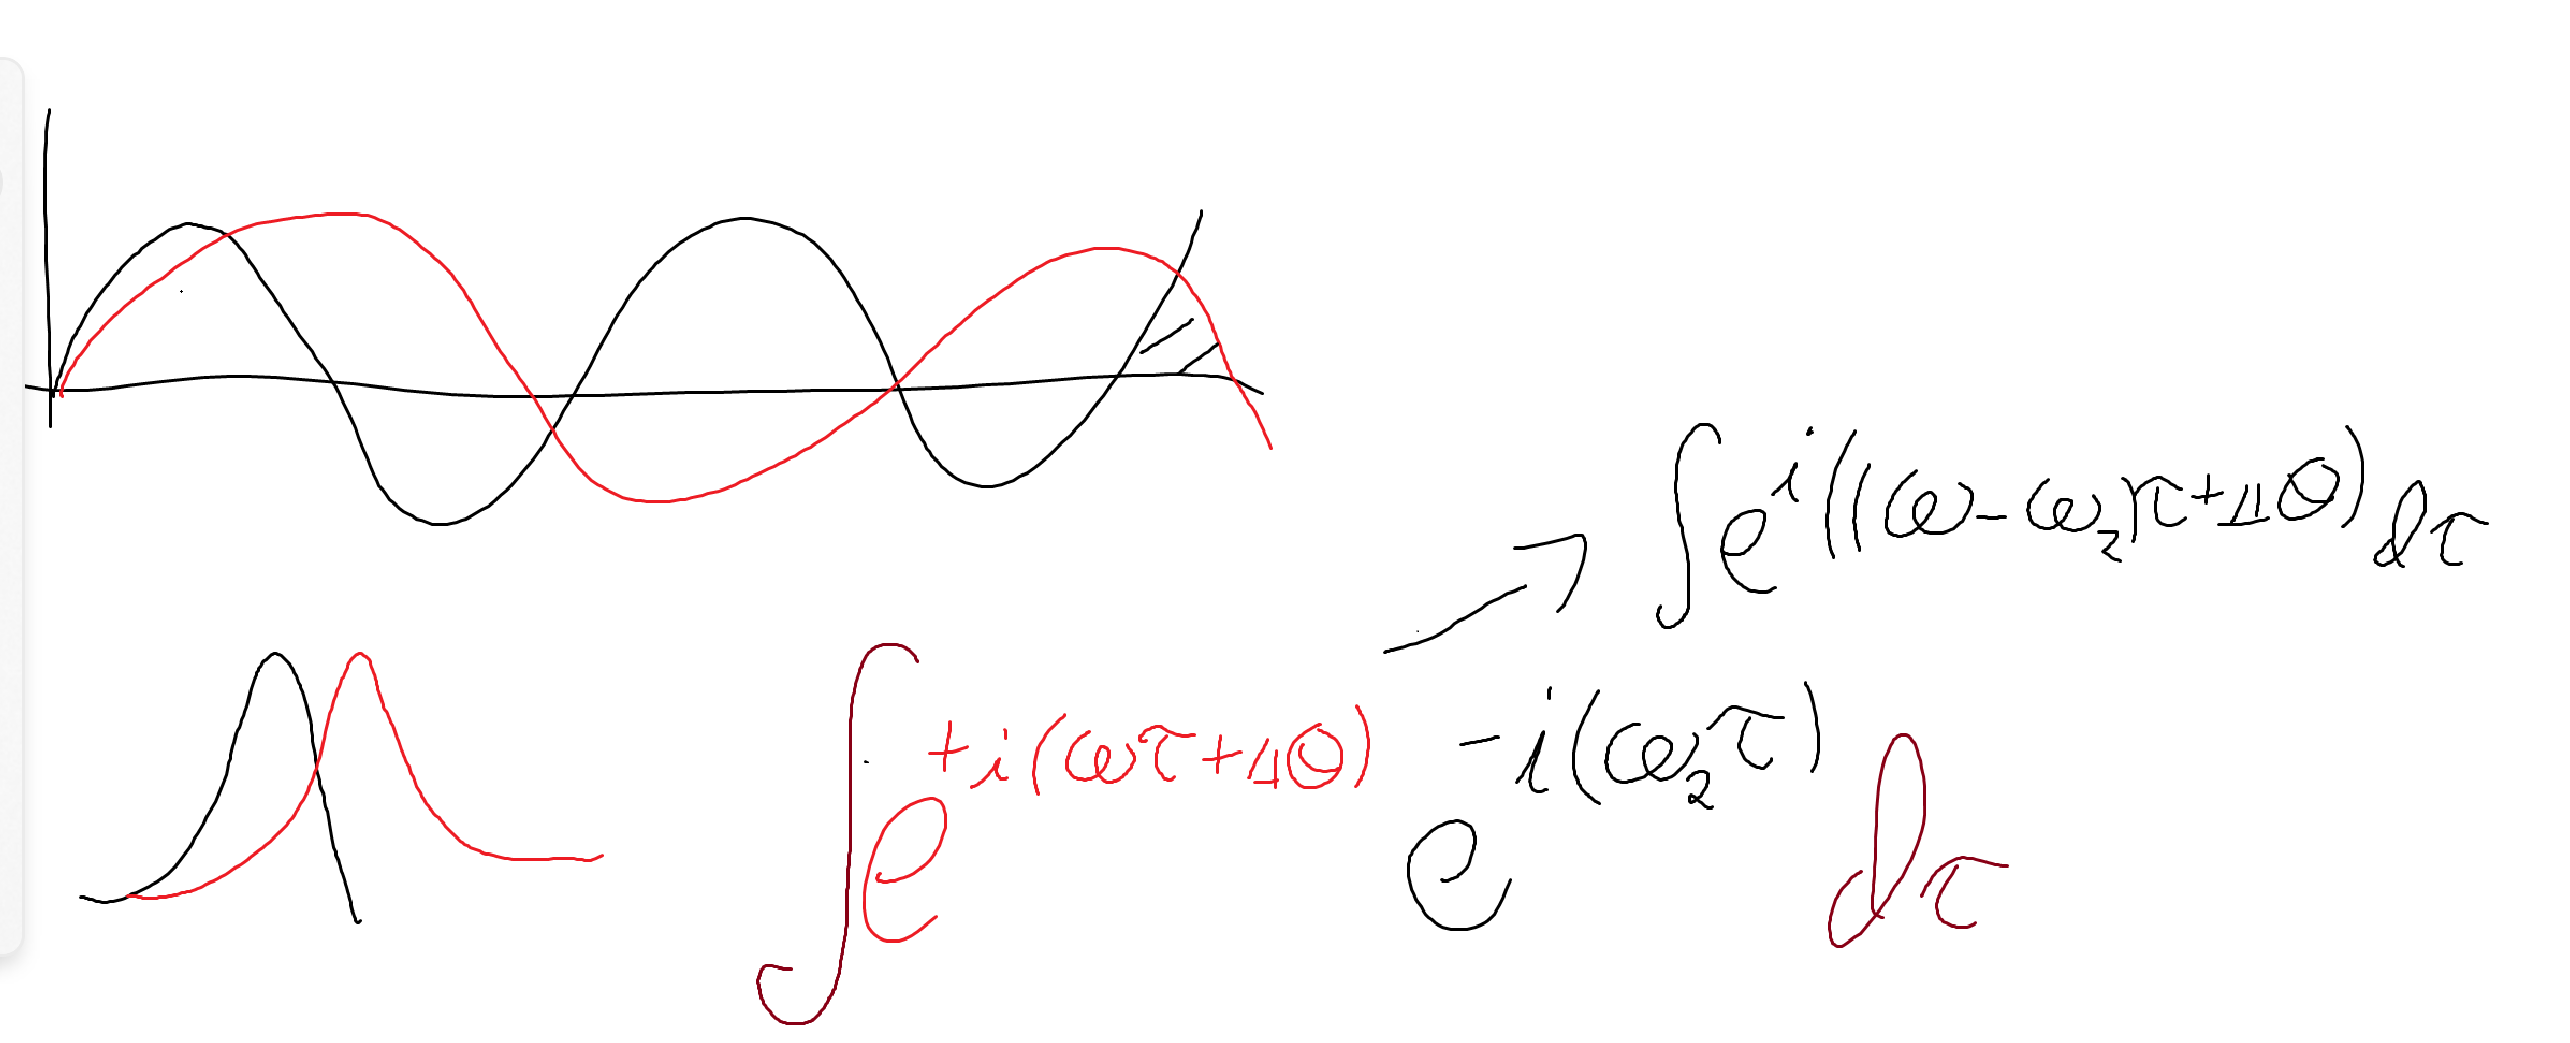

# Task 2 and 3

I decided to do the frequency response right away. The base of the code was yoinked and adapted so many times, that only a small bit remains. Currently the larger DNA overlap is with lab 11


In [5]:
device_name = '/Dev6'

In [3]:
def gen_sine_wave(frequency: float, amplitude: float, offset: float, duration: float, sample_rate: float) -> numpy.typing.NDArray:
    t = np.arange(0, duration, 1/sample_rate)
    wave = amplitude * np.sin(2 * np.pi * frequency * t) + offset
    return wave

In [54]:
total_read = 0
sps = 100000                 
n_samps = 100000
frequencies = np.linspace(1, 150, 15)  

df_freques = pd.DataFrame(columns=['Frequency (Hz)', 'Peak Frequency (Hz)', 'Amplitude', 'Phase'])
raw = []

with nidaqmx.Task() as aitask, nidaqmx.Task() as aotask, nidaqmx.Task() as trigtask:
    aitask.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5, max_val=5
    )
    aitask.ai_channels.add_ai_voltage_chan(
        device_name + "/ai1",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5, max_val=5
    )
    aitask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aitask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # AO: single channel (ao0), finite, triggered by same line
    aotask.ao_channels.add_ao_voltage_chan(device_name + "/ao0")
    aotask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aotask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # Single digital line to issue the trigger
    trigtask.do_channels.add_do_chan(f"{device_name}/port1/line0")

    for i, freq in enumerate(frequencies):
        print(f"Measuring frequency {np.round(freq)} Hz ({i+1}/{len(frequencies)})")

        # Generate AO data: sine wave at current frequency
        ao_data = gen_sine_wave(
            frequency=freq,
            amplitude=2.0,
            offset=0.0,
            duration=n_samps / sps,
            sample_rate=sps
        )
        # Queue AO data but don't autostart
        aotask.write(ao_data, auto_start=False)

        # Arm tasks (important for triggered start)
        aitask.start()
        aotask.start()
        trigtask.start()

        # One trigger pulse → one cycle
        trigtask.write(False)
        trigtask.write(True)

        # Single blocking read of the whole record
        read = np.array(aitask.read(number_of_samples_per_channel=n_samps))

        aitask.stop()
        aotask.stop()
        trigtask.stop()

        raw.append(read)
        
        # Analyze read data
        yf = fft(read[1])
        xf = fftfreq(n_samps, 1/sps)[:n_samps//2]
        peak_freq = xf[np.argmax(2.0/n_samps * np.abs(yf[0:n_samps//2]))]
        amplitude = (2.0/n_samps) * np.max(np.abs(yf[0:n_samps//2]))
        phase = np.angle(yf[np.argmax(2.0/n_samps * np.abs(yf[0:n_samps//2]))])

        df_freques = pd.concat([df_freques, pd.DataFrame({'Frequency (Hz)': [freq], 'Peak Frequency (Hz)': [peak_freq], 'Amplitude': [amplitude], 'Phase': [phase]})], ignore_index=True)


raw = np.array(raw)

Measuring frequency 1.0 Hz (1/15)


C:\Users\leoni\AppData\Local\Temp\ipykernel_28868\2054602268.py:78: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_freques = pd.concat([df_freques, pd.DataFrame({'Frequency (Hz)': [freq], 'Peak Frequency (Hz)': [peak_freq], 'Amplitude': [amplitude], 'Phase': [phase]})], ignore_index=True)


Measuring frequency 12.0 Hz (2/15)
Measuring frequency 22.0 Hz (3/15)
Measuring frequency 33.0 Hz (4/15)
Measuring frequency 44.0 Hz (5/15)
Measuring frequency 54.0 Hz (6/15)
Measuring frequency 65.0 Hz (7/15)
Measuring frequency 76.0 Hz (8/15)
Measuring frequency 86.0 Hz (9/15)
Measuring frequency 97.0 Hz (10/15)
Measuring frequency 107.0 Hz (11/15)
Measuring frequency 118.0 Hz (12/15)
Measuring frequency 129.0 Hz (13/15)
Measuring frequency 139.0 Hz (14/15)
Measuring frequency 150.0 Hz (15/15)


C:\Users\leoni\AppData\Local\Temp\ipykernel_28868\1242275529.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


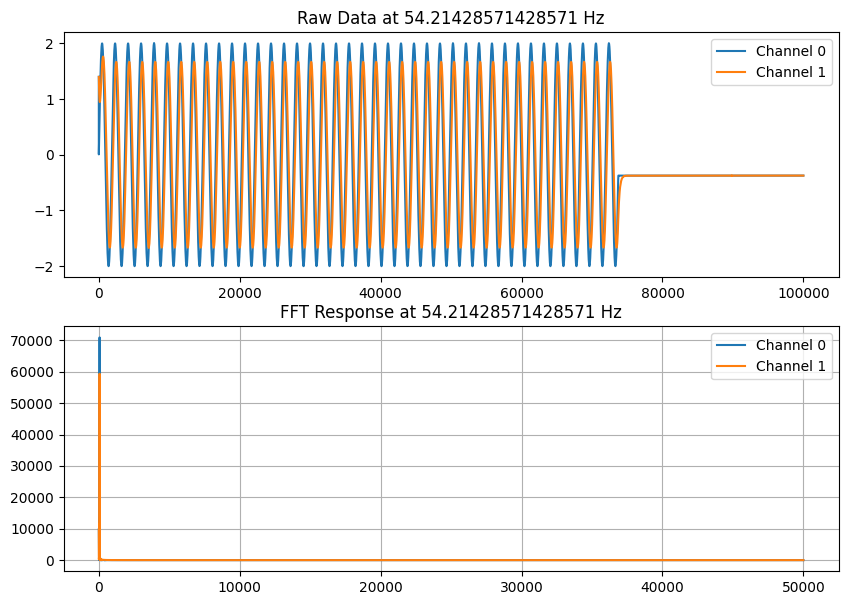

In [59]:
#plot raw data and fft response of nth frequency
fig, ax = plt.subplots(2, figsize = (10,7))
n = 5  # Change n to plot different frequency responses
ax[0].plot(raw[n][0], label='Channel 0')
ax[0].plot(raw[n][1], label='Channel 1')
ax[0].set_title(f'Raw Data at {frequencies[n]} Hz')
ax[0].legend()
yf0 = fft(raw[n,0])
yf1 = fft(raw[n,1])
xf  = fftfreq(n_samps, 1/sps)[:n_samps//2]
ax[1].plot(xf, np.abs(yf0[:n_samps//2]), label='Channel 0')
ax[1].plot(xf, np.abs(yf1[:n_samps//2]), label='Channel 1')
ax[1].set_title(f'FFT Response at {frequencies[n]} Hz')
ax[1].grid()
ax[1].legend()
fig.show()

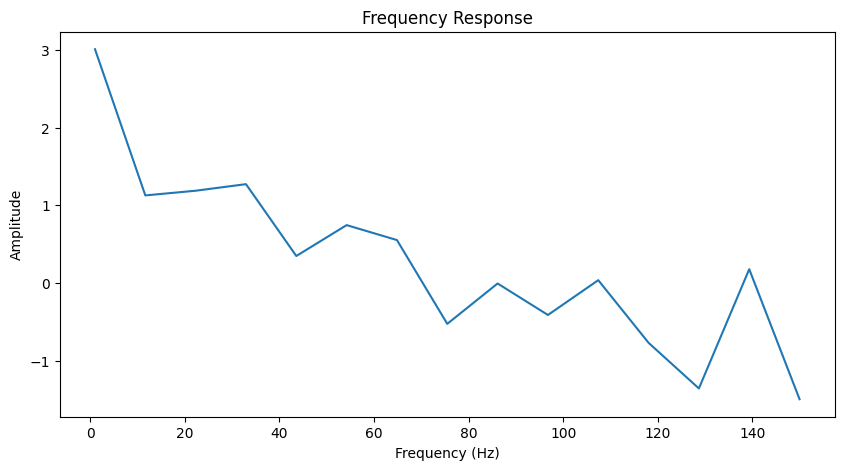

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(df_freques['Frequency (Hz)'], 10*np.log10(df_freques['Amplitude']))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Frequency Response')
plt.show()

Text(0.5, 1.0, 'Phase Response')

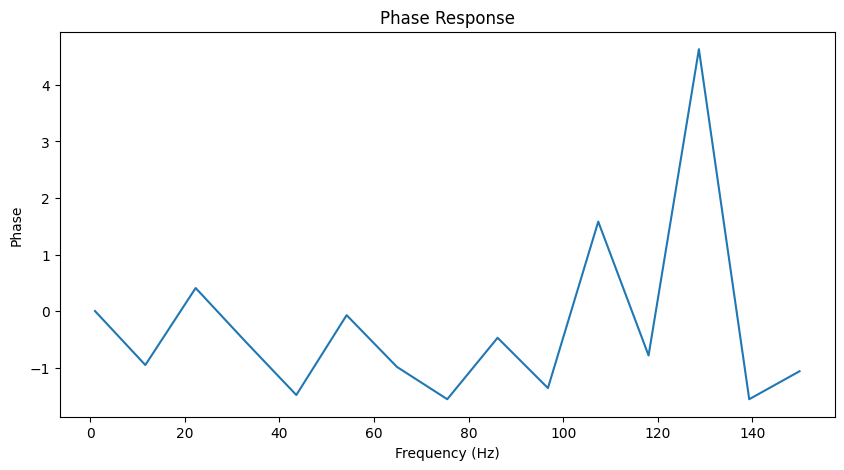

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(df_freques['Frequency (Hz)'], df_freques['Phase']-df_freques['Phase'][0])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase')
plt.title('Phase Response')

# Dump the data

In [72]:
import pickle
with open('lab10_data.pkl', 'wb') as f:
    pickle.dump({'frequencies': frequencies, 'raw': raw, 'df_freques': df_freques}, f)  

# Tasks

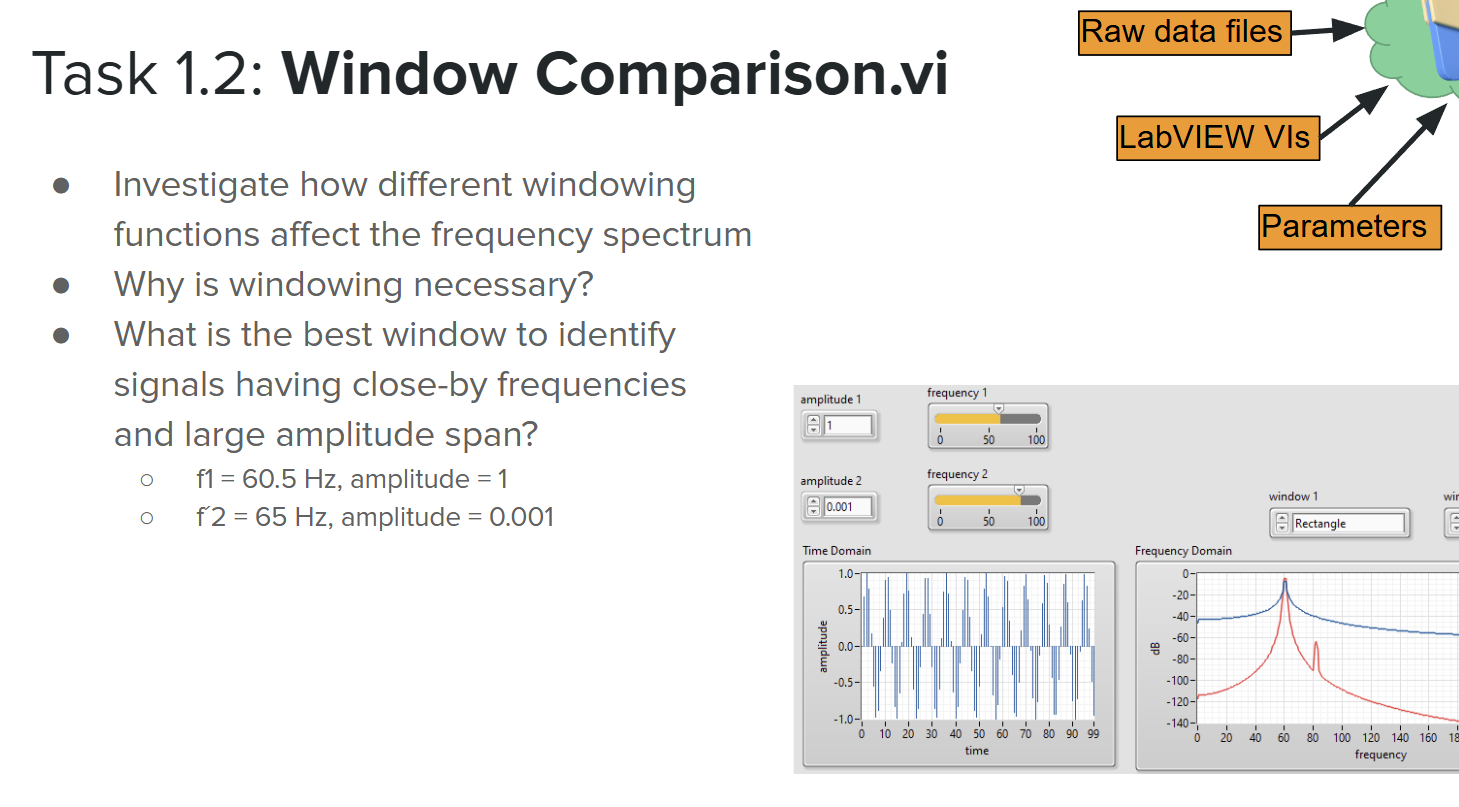

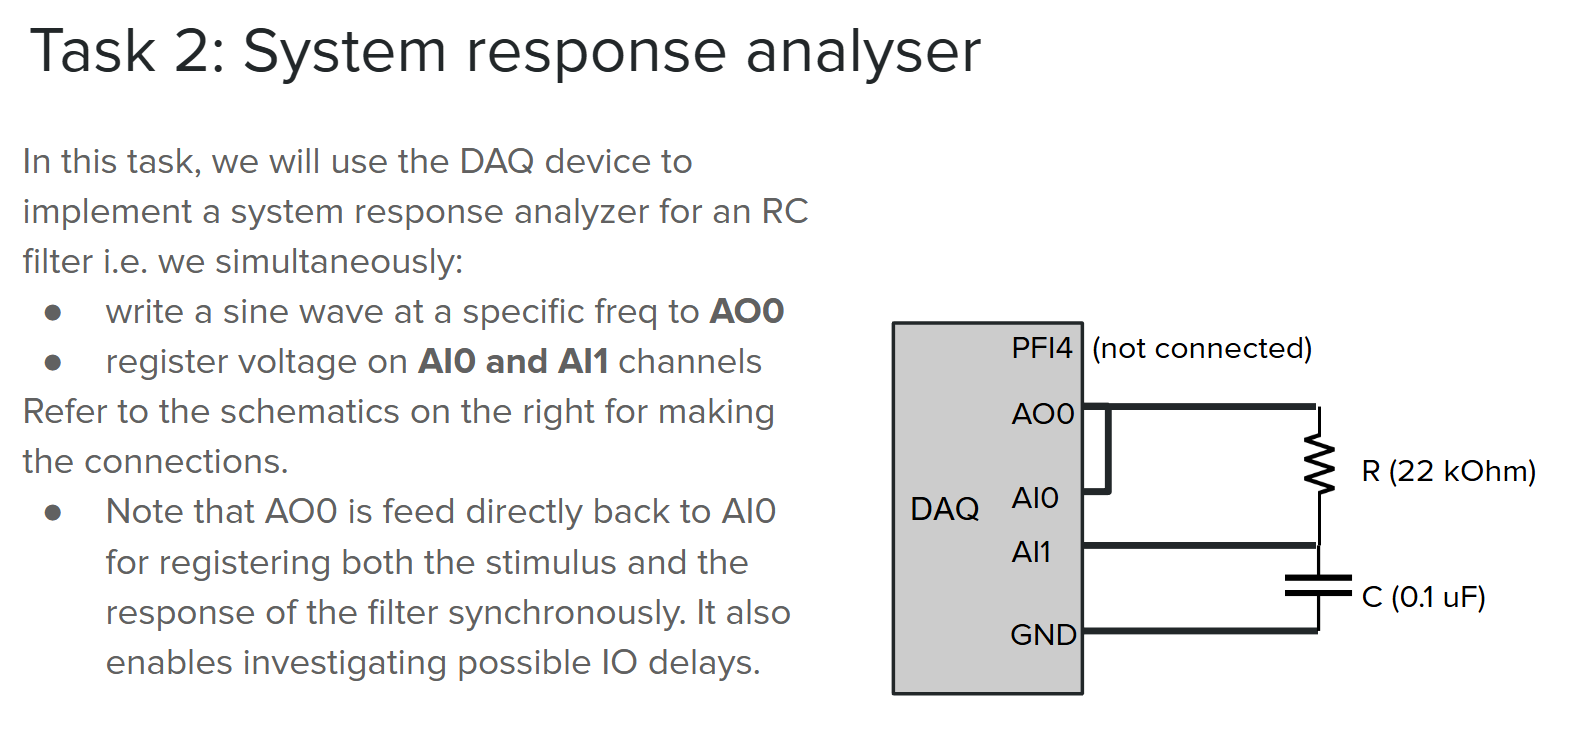
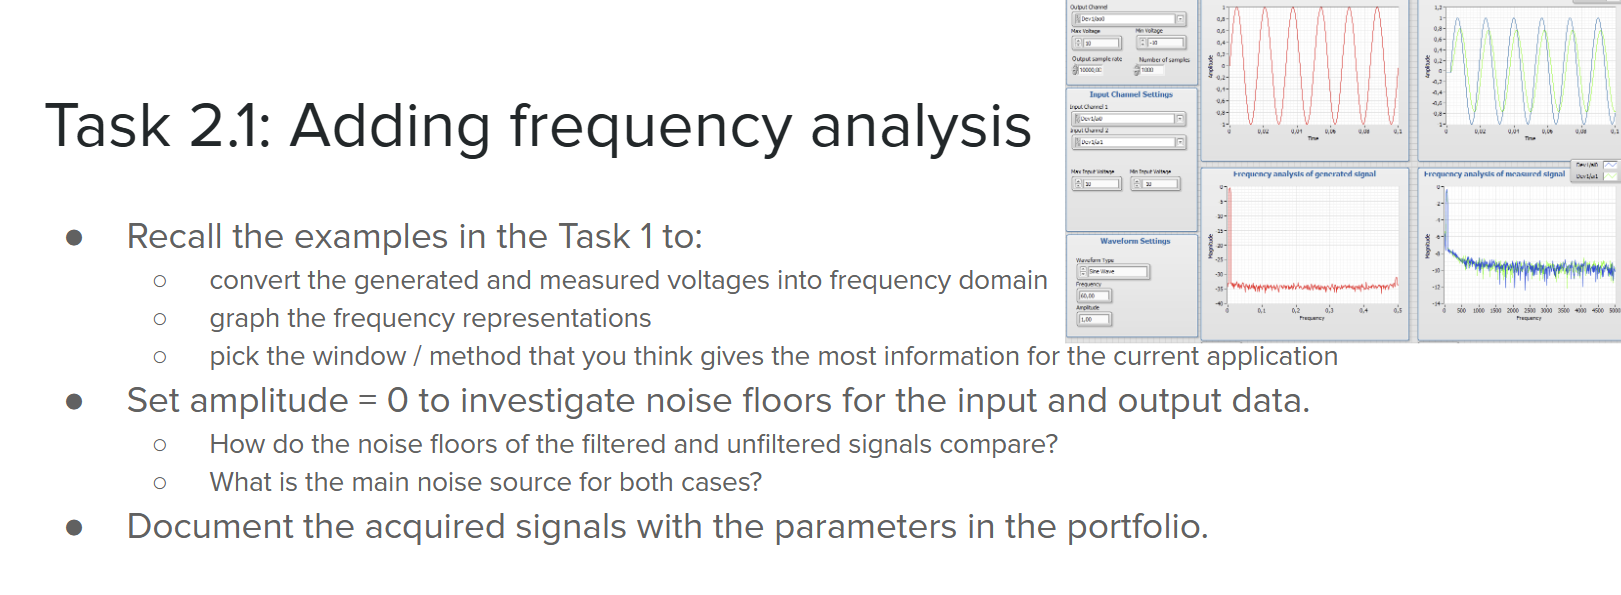
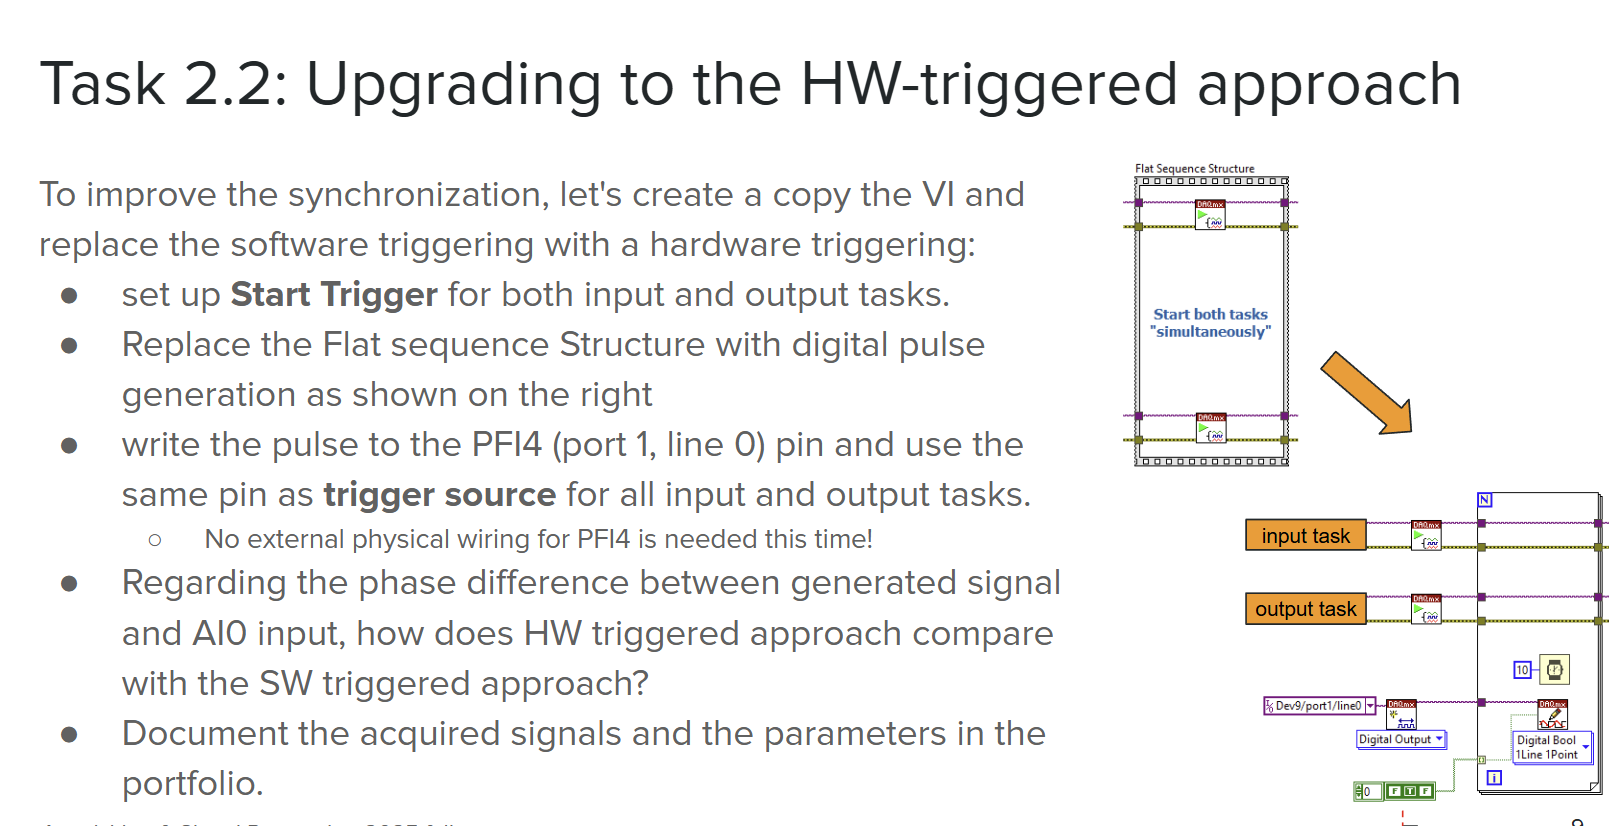

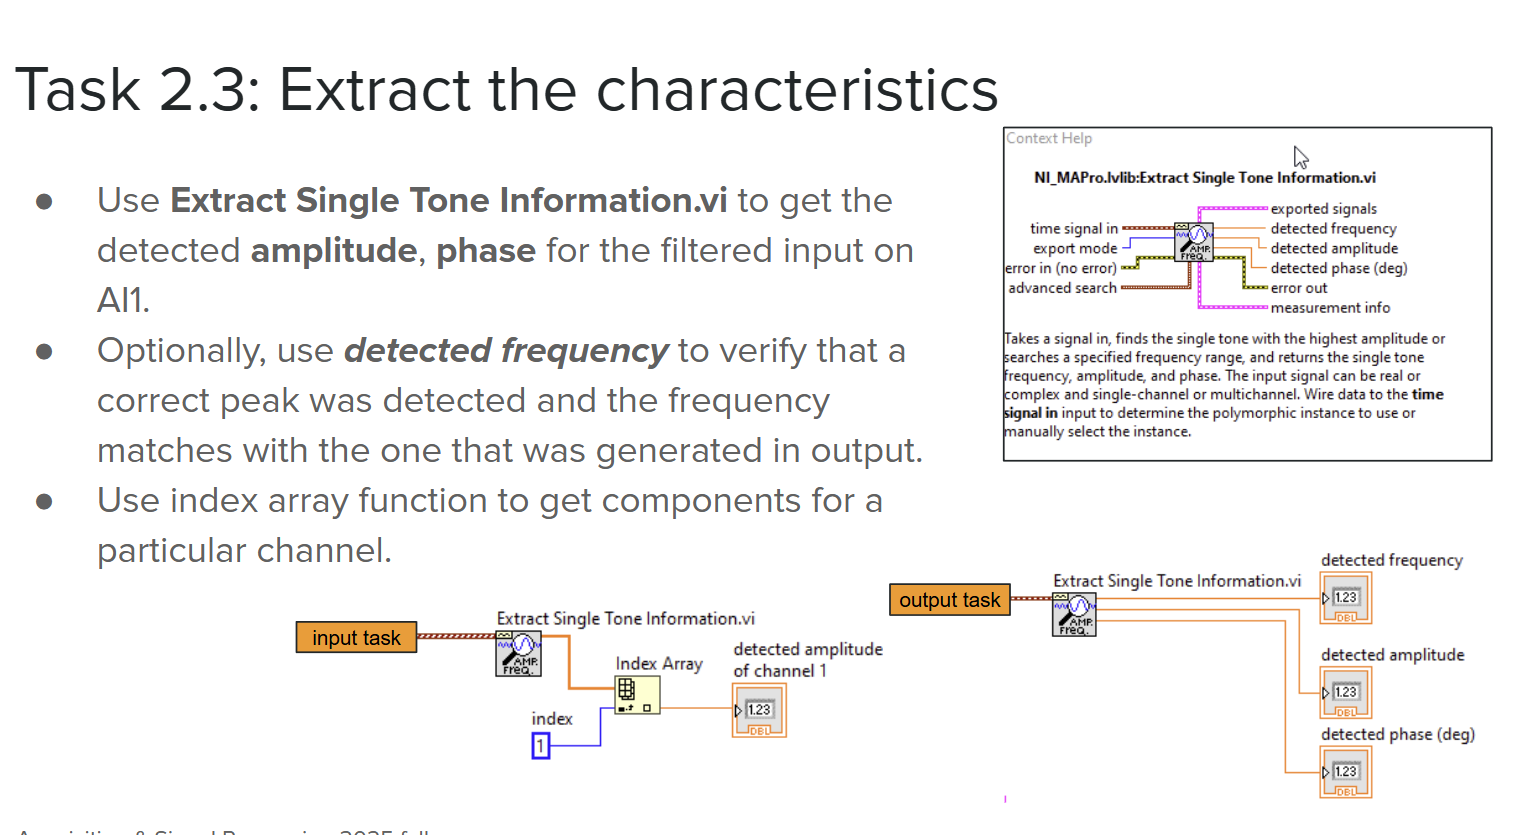
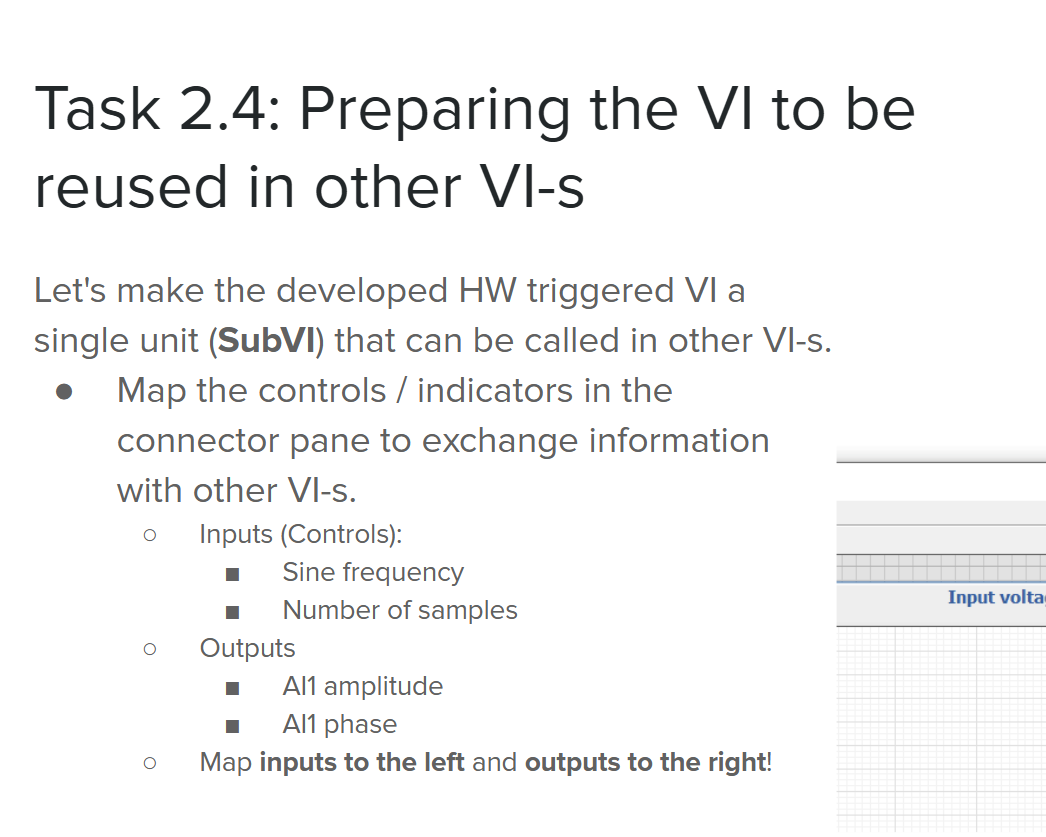

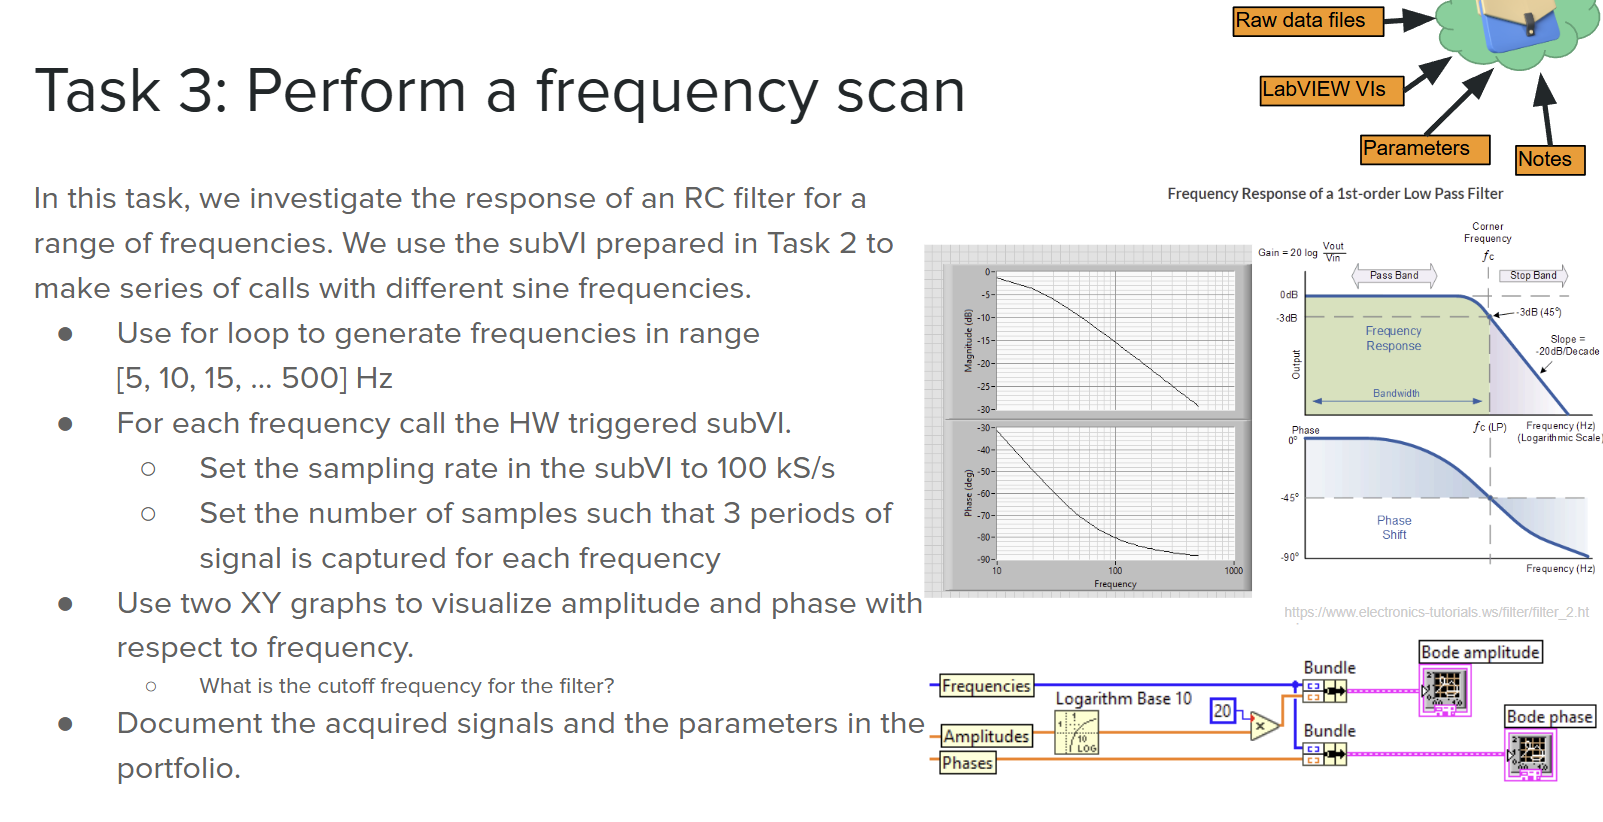